In [18]:
from mdss.ScoringFunctions.Bernoulli import Bernoulli
from mdss.ScoringFunctions.Poisson import Poisson
from mdss.MDSS import MDSS
import seaborn as sns

import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt

In [19]:

import warnings
 # data = pd.read_csv('../sets/project2_data_26_02_24_autostrat1.csv').drop(columns = ['study_id']).fillna(-999)
data = pd.read_csv('~/Downloads/project2_data_26_02_24_autostrat1.csv').drop(columns = ['study_id']).fillna(-999)

target_cols = ['diabetes_status_c_phase1', 'ckd_c_phase1', 'cvd_status_phase1', 'hypertension_status_c_phase1']
data.head()

,age_phase1,site,sex,highest_level_of_education_phase1,partnership_status_c_phase1,ses_site_quintile_c_phase1,occupation_phase1,alcohol_use_status_c_phase1,smoking_status_c_phase1,diabetes_history_phase1,...,change_in_triglycerides,change_in_glucose,change_in_s_creatinine,change_in_insulin,change_in_non_hdl,change_in_egfr,change_in_acr,change_in_mvpa,MAP_phase1,MAP_phase2
0,45.0,3,1,2,1,4,1,3,0,0,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,88.166667,-999.000000
1,46.0,3,1,1,1,2,3,3,1,1,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,111.500000,-999.000000
2,57.0,1,0,0,2,2,2,0,0,0,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,87.500000,-999.000000
3,56.0,1,0,1,2,4,4,0,0,1,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,105.666667,-999.000000
4,56.0,1,1,1,2,2,4,3,2,0,...,-0.01,-0.47,15.88,-999.0,-0.73,-14.779267,-0.301724,2870.0,78.000000,62.666667


In [20]:
site_id = 3 # 1 - Agincourt, 3 - Nairobi

# Choose the relevant site and age group
dff = data[(data['site'] == site_id)].fillna(-999)
# dff = dff2[(dff2['site'] == site_id)& (dff2['age_phase1'] <= 60) & (dff2['age_phase1'] >= 40)].fillna(-999)

print('Original size: ', dff.shape)
dff = dff[(dff[target_cols] != -999).sum(axis = 1) == len(target_cols)].copy()
print('Size after removing records with missing targets: ', dff.shape)

Original size:  (1942, 76)
Size after removing records with missing targets:  (1939, 76)


In [21]:
from IPython.display import Math,display, Markdown
Math(r'F(k) = \int_{-\infty}^{\infty} f(x) \cdot PP')

<IPython.core.display.Math object>

In [22]:
display(Math(r'Dims: {}x{}m \\ Area: {}m^2 \\ Volume: {}m^3'))

<IPython.core.display.Math object>

In [23]:
features = ['age_phase1', 'sex', 'highest_level_of_education_phase1',
       'partnership_status_c_phase1', 'ses_site_quintile_c_phase1',
       'occupation_phase1', 'alcohol_use_status_c_phase1',
       'smoking_status_c_phase1', 'diabetes_history_phase1', 'mvpa_c_phase1',
       'weight_phase1', 'bmi_c_phase1', 'waist_hip_r_c_phase1',
       'waist_circumference_phase1', 'bp_sys_average_phase1','bp_dia_average_phase1',
       'glucose_result_phase1', 's_creatinine_phase1',
       'hdl_phase1', 'cholesterol_1_phase1', 'friedewald_ldl_c_phase1',
       'triglycerides_phase1', 'egfr_c_phase1','acr_c_phase1']
continuous = ['weight_phase1', 'bmi_c_phase1', 'waist_hip_r_c_phase1',
       'waist_circumference_phase1', 'bp_sys_average_phase1','bp_dia_average_phase1',
       'glucose_result_phase1', 's_creatinine_phase1',
       'hdl_phase1', 'cholesterol_1_phase1', 'friedewald_ldl_c_phase1',
       'triglycerides_phase1', 'egfr_c_phase1','acr_c_phase1']

In [24]:
# dff.loc[:,'ckd_c_qcphase1'] = dff.loc[:,'ckd_c_qcphase1'].replace([-999], 0)
dff1 = dff.mask(dff.isin([-999, -222, -111, 999]))

In [25]:
from sklearn.linear_model import BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
imputer_bayes = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42)

# let's create a MICE imputer using Bayes as estimator

imputer = IterativeImputer(
    estimator=BayesianRidge(), # the estimator to predict the NA
    initial_strategy='mean', # how will NA be imputed in step 1
    max_iter=10, # number of cycles
    imputation_order='ascending', # the order in which to impute the variables
    n_nearest_features=None, # whether to limit the number of predictors
    skip_complete=True, # whether to ignore variables without NA
    random_state=0,
)
imputer.fit(dff1[continuous])
train_t = imputer.transform(dff1[continuous])
# train_x = imputer.transform(data.iloc[:,2:])
treated = pd.DataFrame(train_t, columns=dff1[continuous].columns)
# treated = treated.apply(np.ceil)
# treated.loc[:,['highest_level_of_education_qc','occupation_qc','smoking_status_c_qc']]\
#       = np.round(treated.loc[:,['highest_level_of_education_qc','occupation_qc','smoking_status_c_qc']], decimals=0)


In [26]:
# variables = {
#     'bmi_c_phase1': 'BMI',
#     'triglycerides_phase1': 'Triglycerides',
#     'egfr_c_phase1': 'EGFR',
#     'cholesterol_1_phase1': 'Cholesterol'
# }
# colors = ['brown', 'lightblue']

# # Create subplots
# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()

# for ax, (var, var_name) in zip(axes, variables.items()):
#     dff1[var].plot(kind='kde', ax=ax, color=colors[0], label='Before Imputation')
#     treated[var].plot(kind='kde', ax=ax, color=colors[1], label='After Imputation')
#     ax.set_title(f'Distribution of {var_name}')
#     ax.set_xlabel(var_name)
#     ax.set_ylabel('Density')
#     ax.legend()
#     ax.grid(True)

# plt.tight_layout()
# # Save the figure as .eps
# fig.savefig("/Users/kayadetunji/Downloads/figs/distributions_ag.eps", format='eps')

# # Save the figure as a vector-based PDF
# fig.savefig("/Users/kayadetunji/Downloads/figs/distributions_ag.pdf", format='pdf')
# plt.show()

In [27]:
dff = dff[features + target_cols].copy()
dff.reset_index(inplace=True, drop=True)
dff[continuous] = treated[continuous]
dff['age_phase1'] = dff.age_phase1.astype(int)

In [28]:
# Specify the columns of interest
# columns_of_interest = ['htn_jnc7_qc', 'diabetes_status_c_qc', 'ckd_c_qc', 'cadiovascular_current'] 


# defining the outcome variable
dff['MorbidityCount'] = (dff[target_cols] == 1).sum(axis = 1) # *******CHECK*********
treated['MorbidityCount'] = (dff[target_cols] == 1).sum(axis = 1)

# Min-Max Normalization
# treated['normalizedOutcome'] = (treated['MorbidityCount'] - treated['MorbidityCount'].min()) / (treated['MorbidityCount'].max() - treated['MorbidityCount'].min())


# defining the expectations as mean of the target
# treated['expectation'] = treated[target_col].mean()
# treated['expectationPoisson'] = treated['normalizedOutcome'].mean()
treated['expectationPoisson'] = treated['MorbidityCount'].mean()
dff['expectationPoisson'] = dff['MorbidityCount'].mean()

In [29]:
NA = dff
dff_nai = dff

In [17]:
AG = dff
dff_ag = dff


In [30]:
import numpy as np
import pandas as pd

# ============================================================
# USER SETTINGS
# ============================================================

AGE_COL = 'age_phase1'              # <-- change if needed
OUTCOME_COL = 'MorbidityCount'

# ============================================================
# BASIC AGE SUMMARY
# ============================================================

def age_summary(df, site_name, age_col=AGE_COL):
    
    age = pd.to_numeric(df[age_col], errors='coerce').dropna()

    return {
        'Site': site_name,
        'N': len(df),
        'Age_n': len(age),
        'Age_mean': age.mean(),
        'Age_SD': age.std(),
        'Age_median': age.median(),
        'Age_Q1': age.quantile(0.25),
        'Age_Q3': age.quantile(0.75),
        'Age_min': age.min(),
        'Age_max': age.max(),
        'Age_>=45_n': (age >= 45).sum(),
        'Age_>=45_%': 100 * (age >= 45).mean(),
        'Age_>=50_n': (age >= 50).sum(),
        'Age_>=50_%': 100 * (age >= 50).mean(),
        'Age_>=53_n': (age >= 53).sum(),
        'Age_>=53_%': 100 * (age >= 53).mean(),
        'Age_>=54_n': (age >= 54).sum(),
        'Age_>=54_%': 100 * (age >= 54).mean()
    }


age_summary_table = pd.DataFrame([
    age_summary(dff_ag, 'Agincourt'),
    age_summary(dff_nai, 'Nairobi')
])

# round numerical values for display
display_table = age_summary_table.copy()

for col in display_table.columns:
    if col not in ['Site', 'N', 'Age_n',
                   'Age_>=45_n', 'Age_>=50_n',
                   'Age_>=53_n', 'Age_>=54_n']:
        display_table[col] = display_table[col].round(2)

display(display_table)

,Site,N,Age_n,Age_mean,Age_SD,Age_median,Age_Q1,Age_Q3,Age_min,Age_max,Age_>=45_n,Age_>=45_%,Age_>=50_n,Age_>=50_%,Age_>=53_n,Age_>=53_%,Age_>=54_n,Age_>=54_%
0,Agincourt,1395,1395,50.91,5.90,51.0,46.0,56.0,38,70,1116,80.00,849,60.86,601,43.08,532,38.14
1,Nairobi,1939,1939,48.86,5.73,48.0,44.0,53.0,30,67,1412,72.82,825,42.55,537,27.69,438,22.59


In [31]:
display_table.T

,0,1
Site,Agincourt,Nairobi
N,1395,1939
Age_n,1395,1939
Age_mean,50.91,48.86
Age_SD,5.9,5.73
Age_median,51.0,48.0
Age_Q1,46.0,44.0
Age_Q3,56.0,53.0
Age_min,38,30
Age_max,70,67


In [32]:
# ============================================================
# CREATE COMMON 5-YEAR AGE BANDS ACROSS BOTH SITES
# ============================================================

pooled_age = pd.concat([
    pd.to_numeric(dff_ag[AGE_COL], errors='coerce'),
    pd.to_numeric(dff_nai[AGE_COL], errors='coerce')
]).dropna()

age_start = int(np.floor(pooled_age.min() / 5) * 5)
age_end = int(np.ceil((pooled_age.max() + 1) / 5) * 5)

age_bins = np.arange(age_start, age_end + 1, 5)

print("Age-bin edges:", age_bins)


def prepare_site(df, site_name):
    temp = df.copy()
    temp['Site'] = site_name

    temp['Age_band'] = pd.cut(
        temp[AGE_COL],
        bins=age_bins,
        right=False,
        include_lowest=True
    )

    return temp


ag_plot = prepare_site(dff_ag, 'Agincourt')
nai_plot = prepare_site(dff_nai, 'Nairobi')

combined = pd.concat(
    [ag_plot, nai_plot],
    ignore_index=True
)

combined['Age_band_label'] = combined['Age_band'].apply(
    lambda x: f"{int(x.left)}–{int(x.right - 1)}"
    if pd.notna(x) else np.nan
)

Age-bin edges: [30 35 40 45 50 55 60 65 70 75]


In [33]:
# ============================================================
# AGE-BAND COUNTS AND PERCENTAGES
# ============================================================

age_band_counts = (
    combined
    .dropna(subset=['Age_band_label'])
    .groupby(['Site', 'Age_band_label'], observed=True)
    .size()
    .reset_index(name='n')
)

site_totals = (
    combined
    .groupby('Site')
    .size()
    .rename('N')
    .reset_index()
)

age_band_counts = age_band_counts.merge(
    site_totals,
    on='Site',
    how='left'
)

age_band_counts['Percent'] = (
    100 * age_band_counts['n'] /
    age_band_counts['N']
)

age_band_counts['Percent'] = age_band_counts['Percent'].round(1)

display(age_band_counts)

,Site,Age_band_label,n,N,Percent
0,Agincourt,35–39,1,1395,0.1
1,Agincourt,40–44,278,1395,19.9
2,Agincourt,45–49,267,1395,19.1
3,Agincourt,50–54,407,1395,29.2
4,Agincourt,55–59,368,1395,26.4
5,Agincourt,60–64,71,1395,5.1
6,Agincourt,65–69,2,1395,0.1
7,Agincourt,70–74,1,1395,0.1
8,Nairobi,30–34,2,1939,0.1
9,Nairobi,35–39,22,1939,1.1


In [34]:
def standardized_mean_difference(x1, x2):
    x1 = pd.to_numeric(x1, errors='coerce').dropna()
    x2 = pd.to_numeric(x2, errors='coerce').dropna()

    pooled_sd = np.sqrt(
        (x1.var(ddof=1) + x2.var(ddof=1)) / 2
    )

    return (x1.mean() - x2.mean()) / pooled_sd


age_smd = standardized_mean_difference(
    dff_ag[AGE_COL],
    dff_nai[AGE_COL]
)

print(f"Age SMD (Agincourt - Nairobi): {age_smd:.3f}")

Age SMD (Agincourt - Nairobi): 0.353


In [35]:
from scipy.stats import ks_2samp

age_ag = pd.to_numeric(
    dff_ag[AGE_COL],
    errors='coerce'
).dropna()

age_nai = pd.to_numeric(
    dff_nai[AGE_COL],
    errors='coerce'
).dropna()

ks_stat, ks_p = ks_2samp(age_ag, age_nai)

print(f"KS statistic: {ks_stat:.3f}")
print(f"KS p-value: {ks_p:.4g}")

KS statistic: 0.186
KS p-value: 5.43e-25


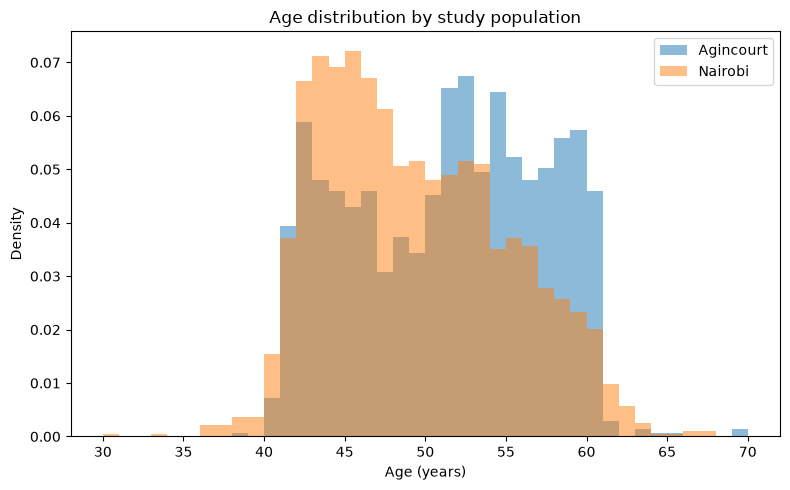

In [36]:
import matplotlib.pyplot as plt

# ============================================================
# PANEL A — AGE DISTRIBUTION
# ============================================================

all_age = pd.concat([age_ag, age_nai])

hist_bins = np.arange(
    np.floor(all_age.min()),
    np.ceil(all_age.max()) + 1,
    1
)

plt.figure(figsize=(8, 5))

plt.hist(
    age_ag,
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label='Agincourt'
)

plt.hist(
    age_nai,
    bins=hist_bins,
    density=True,
    alpha=0.5,
    label='Nairobi'
)

plt.xlabel('Age (years)')
plt.ylabel('Density')
plt.title('Age distribution by study population')
plt.legend()
plt.tight_layout()
plt.show()

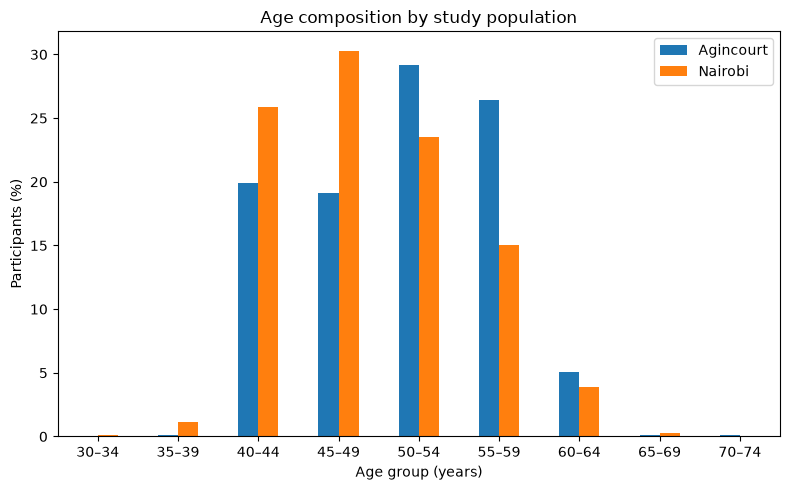

In [37]:
# ============================================================
# PANEL B — AGE-BAND DISTRIBUTION
# ============================================================

pivot_age = (
    age_band_counts
    .pivot(
        index='Age_band_label',
        columns='Site',
        values='Percent'
    )
)

pivot_age.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Age group (years)')
plt.ylabel('Participants (%)')
plt.title('Age composition by study population')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# AGE-SPECIFIC MULTIMORBIDITY BURDEN
# ============================================================

age_burden = (
    combined
    .dropna(subset=['Age_band_label', OUTCOME_COL])
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )[OUTCOME_COL]
    .agg(
        n='size',
        mean='mean',
        sd='std'
    )
    .reset_index()
)

age_burden['se'] = (
    age_burden['sd'] /
    np.sqrt(age_burden['n'])
)

age_burden['ci_low'] = (
    age_burden['mean'] -
    1.96 * age_burden['se']
)

age_burden['ci_high'] = (
    age_burden['mean'] +
    1.96 * age_burden['se']
)

display(age_burden)

,Site,Age_band_label,n,mean,sd,se,ci_low,ci_high
0,Agincourt,35–39,1,0.000000,NaN,NaN,NaN,NaN
1,Agincourt,40–44,278,0.521583,0.661937,0.039700,0.443770,0.599395
2,Agincourt,45–49,267,0.689139,0.712927,0.043630,0.603623,0.774654
3,Agincourt,50–54,407,0.798526,0.738590,0.036611,0.726769,0.870282
4,Agincourt,55–59,368,1.024457,0.826634,0.043091,0.939998,1.108915
5,Agincourt,60–64,71,0.929577,0.780548,0.092634,0.748015,1.111140
6,Agincourt,65–69,2,1.000000,0.000000,0.000000,1.000000,1.000000
7,Agincourt,70–74,1,2.000000,NaN,NaN,NaN,NaN
8,Nairobi,30–34,2,0.000000,0.000000,0.000000,0.000000,0.000000
9,Nairobi,35–39,22,0.272727,0.455842,0.097186,0.082243,0.463212


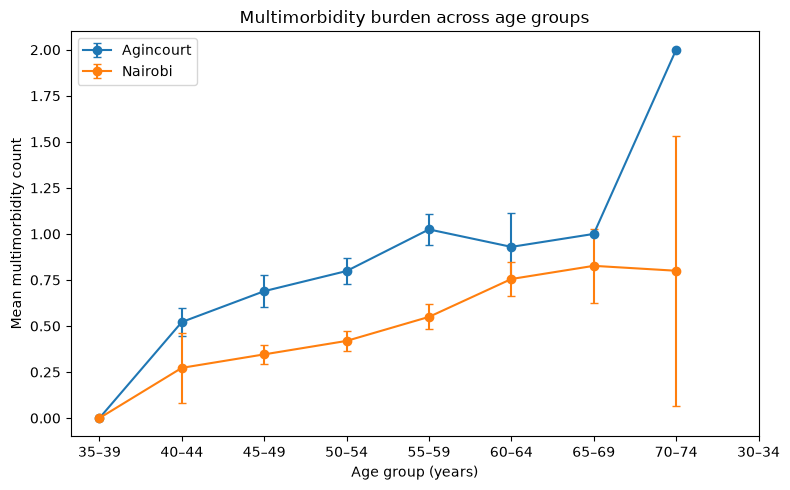

In [39]:
# ============================================================
# PANEL C — MEAN MULTIMORBIDITY COUNT BY AGE GROUP
# ============================================================

plt.figure(figsize=(8, 5))

for site in ['Agincourt', 'Nairobi']:

    temp = age_burden[
        age_burden['Site'] == site
    ].copy()

    x = np.arange(len(temp))

    plt.errorbar(
        x,
        temp['mean'],
        yerr=[
            temp['mean'] - temp['ci_low'],
            temp['ci_high'] - temp['mean']
        ],
        marker='o',
        capsize=3,
        label=site
    )

# use labels appearing in the data
age_labels = (
    age_burden['Age_band_label']
    .drop_duplicates()
    .tolist()
)

plt.xticks(
    np.arange(len(age_labels)),
    age_labels
)

plt.xlabel('Age group (years)')
plt.ylabel('Mean multimorbidity count')
plt.title('Multimorbidity burden across age groups')
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

WHR_COL = 'waist_hip_r_c_phase1'   # change to your actual variable name

def continuous_summary(df, site, col):
    x = pd.to_numeric(df[col], errors='coerce').dropna()

    return {
        'Site': site,
        'N_total': len(df),
        'N_available': len(x),
        'Missing_n': len(df) - len(x),
        'Missing_%': 100 * (len(df) - len(x)) / len(df),
        'Mean': x.mean(),
        'SD': x.std(),
        'Median': x.median(),
        'Q1': x.quantile(0.25),
        'Q3': x.quantile(0.75),
        'Min': x.min(),
        'Max': x.max()
    }

whr_summary = pd.DataFrame([
    continuous_summary(dff_ag, 'Agincourt', WHR_COL),
    continuous_summary(dff_nai, 'Nairobi', WHR_COL)
])

display(whr_summary.round(3))

,Site,N_total,N_available,Missing_n,Missing_%,Mean,SD,Median,Q1,Q3,Min,Max
0,Agincourt,1395,1395,0,0.0,0.901,0.076,0.90,0.85,0.95,0.59,1.16
1,Nairobi,1939,1939,0,0.0,0.894,0.256,0.88,0.84,0.93,0.65,9.02


In [41]:
whr_ag = pd.to_numeric(
    dff_ag[WHR_COL], errors='coerce'
).dropna()

whr_nai = pd.to_numeric(
    dff_nai[WHR_COL], errors='coerce'
).dropna()

# Standardized mean difference
pooled_sd = np.sqrt(
    (whr_ag.var(ddof=1) + whr_nai.var(ddof=1)) / 2
)

whr_smd = (
    whr_ag.mean() - whr_nai.mean()
) / pooled_sd

# KS test
ks_whr, p_whr = ks_2samp(whr_ag, whr_nai)

print(f'WHR SMD (Agincourt - Nairobi): {whr_smd:.3f}')
print(f'WHR KS statistic: {ks_whr:.3f}')
print(f'WHR KS p-value: {p_whr:.4g}')

WHR SMD (Agincourt - Nairobi): 0.035
WHR KS statistic: 0.082
WHR KS p-value: 3.009e-05


In [38]:
def whr_threshold_summary(df, site, col):
    x = pd.to_numeric(df[col], errors='coerce').dropna()

    return {
        'Site': site,
        'N': len(x),
        'WHR >= 0.87 n': int((x >= 0.87).sum()),
        'WHR >= 0.87 %': 100 * (x >= 0.87).mean(),
        'WHR >= 0.90 n': int((x >= 0.90).sum()),
        'WHR >= 0.90 %': 100 * (x >= 0.90).mean()
    }

whr_thresholds = pd.DataFrame([
    whr_threshold_summary(dff_ag, 'Agincourt', WHR_COL),
    whr_threshold_summary(dff_nai, 'Nairobi', WHR_COL)
])

display(whr_thresholds.round(2))

,Site,N,WHR >= 0.87 n,WHR >= 0.87 %,WHR >= 0.90 n,WHR >= 0.90 %
0,Agincourt,1395,928,66.52,711,50.97
1,Nairobi,1939,1176,60.65,834,43.01


In [42]:
def whr_threshold_summary(df, site, col):
    x = pd.to_numeric(df[col], errors='coerce').dropna()

    return {
        'Site': site,
        'N': len(x),
        'WHR >= 0.87 n': int((x >= 0.87).sum()),
        'WHR >= 0.87 %': 100 * (x >= 0.87).mean(),
        'WHR >= 0.90 n': int((x >= 0.90).sum()),
        'WHR >= 0.90 %': 100 * (x >= 0.90).mean()
    }

whr_thresholds = pd.DataFrame([
    whr_threshold_summary(dff_ag, 'Agincourt', WHR_COL),
    whr_threshold_summary(dff_nai, 'Nairobi', WHR_COL)
])

display(whr_thresholds.round(2))

,Site,N,WHR >= 0.87 n,WHR >= 0.87 %,WHR >= 0.90 n,WHR >= 0.90 %
0,Agincourt,1395,928,66.52,711,50.97
1,Nairobi,1939,1176,60.65,834,43.01


In [43]:
def prepare_age_whr(df, site):
    temp = df[[AGE_COL, WHR_COL, OUTCOME_COL]].copy()
    temp['Site'] = site

    temp['Age_band'] = pd.cut(
        temp[AGE_COL],
        bins=age_bins,
        right=False,
        include_lowest=True
    )

    temp['Age_band_label'] = temp['Age_band'].apply(
        lambda x: f"{int(x.left)}–{int(x.right - 1)}"
        if pd.notna(x) else np.nan
    )

    return temp

age_whr = pd.concat([
    prepare_age_whr(dff_ag, 'Agincourt'),
    prepare_age_whr(dff_nai, 'Nairobi')
], ignore_index=True)

whr_by_age = (
    age_whr[
        age_whr['Age_band_label'].isin(
            ['40–44', '45–49', '50–54', '55–59', '60–64']
        )
    ]
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )[WHR_COL]
    .agg(
        n='count',
        mean='mean',
        sd='std',
        median='median'
    )
    .reset_index()
)

whr_by_age['se'] = (
    whr_by_age['sd'] / np.sqrt(whr_by_age['n'])
)

whr_by_age['ci_low'] = (
    whr_by_age['mean'] - 1.96 * whr_by_age['se']
)

whr_by_age['ci_high'] = (
    whr_by_age['mean'] + 1.96 * whr_by_age['se']
)

display(whr_by_age.round(3))

,Site,Age_band_label,n,mean,sd,median,se,ci_low,ci_high
0,Agincourt,40–44,278,0.873,0.071,0.87,0.004,0.864,0.881
1,Agincourt,45–49,267,0.893,0.079,0.88,0.005,0.884,0.903
2,Agincourt,50–54,407,0.903,0.070,0.90,0.003,0.896,0.909
3,Agincourt,55–59,368,0.920,0.080,0.91,0.004,0.912,0.928
4,Agincourt,60–64,71,0.923,0.064,0.92,0.008,0.908,0.938
5,Nairobi,40–44,503,0.890,0.369,0.87,0.016,0.857,0.922
6,Nairobi,45–49,587,0.890,0.306,0.87,0.013,0.865,0.914
7,Nairobi,50–54,455,0.895,0.070,0.89,0.003,0.889,0.902
8,Nairobi,55–59,290,0.903,0.068,0.90,0.004,0.896,0.911
9,Nairobi,60–64,75,0.917,0.069,0.92,0.008,0.901,0.933


In [44]:
age_whr['WHR_ge_087'] = (
    age_whr[WHR_COL] >= 0.87
).astype(int)

age_whr['WHR_ge_090'] = (
    age_whr[WHR_COL] >= 0.90
).astype(int)

whr_threshold_by_age = (
    age_whr[
        age_whr['Age_band_label'].isin(
            ['40–44', '45–49', '50–54', '55–59', '60–64']
        )
    ]
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )
    .agg(
        n=(WHR_COL, 'count'),
        WHR_ge_087_pct=('WHR_ge_087', 'mean'),
        WHR_ge_090_pct=('WHR_ge_090', 'mean')
    )
    .reset_index()
)

whr_threshold_by_age['WHR_ge_087_pct'] *= 100
whr_threshold_by_age['WHR_ge_090_pct'] *= 100

display(whr_threshold_by_age.round(1))

,Site,Age_band_label,n,WHR_ge_087_pct,WHR_ge_090_pct
0,Agincourt,40–44,278,52.9,36.7
1,Agincourt,45–49,267,59.2,44.6
2,Agincourt,50–54,407,70.0,52.3
3,Agincourt,55–59,368,76.1,61.7
4,Agincourt,60–64,71,77.5,66.2
5,Nairobi,40–44,503,54.7,34.0
6,Nairobi,45–49,587,54.2,39.0
7,Nairobi,50–54,455,65.9,47.9
8,Nairobi,55–59,290,71.7,54.5
9,Nairobi,60–64,75,80.0,62.7


In [45]:
numeric_columns = [col for col in dff.columns \
                     if (is_numeric_dtype(dff[col])) \
                     & (col not in target_cols) \
                     & (dff[col].nunique() > 10)]

In [46]:
# Defining the search space to be all the features except site, study_id, 
# and our created target_col and expectations columns

search_space1 = [col for col in dff.columns \
                if col not in \
                ['age_phase2','index','site',
       'diabetes_status_c_phase2', 'hypertension_status_phase2',
       'smoking_status_c_phase2', 'diabetes_history_phase2', 'mvpa_c_phase2',
       'weight_phase2', 'bmi_c_phase2', 'waist_circumference_phase2',
       'waist_hip_r_c_phase2', 'bp_sys_average_phase2','hypertension_status_c_phase1','diabetes_status_c_phase1','non_hdl_c_phase1',
       'bp_dia_average_phase2', 'fasting_confirmed_phase2','hip_circumference_phase1', 'hip_circumference_phase2',
       'glucose_result_phase2', 's_creatinine_phase2', 'insulin_result_phase2', 'cholesterol_1_phase2', 'friedewald_ldl_c_phase2',
       'triglycerides_phase2', 'non_hdl_c_phase2', 'egfr_c_phase2','acr_c_phase2', 'change_in_weight', 'change_in_bmi',
       'change_in_waist_hip_ratio', 'change_in_waist_circf','change_in_systolic_ave', 'change_in_diastolic_ave',
       'change_in_cholesterol', 'change_in_friedewald', 'change_in_hdl', 'bp_sys_average_phase1',
       'change_in_triglycerides', 'change_in_glucose','ckd_c_phase1', 'bp_dia_average_phase1', 'acr_c_phase1',
 'cvd_status_phase1','insulin_result_phase1','hdl_phase2','fasting_confirmation_phase1','weight_phase1','partnership_status_c_phase1',
       'change_in_s_creatinine', 'change_in_insulin', 'change_in_non_hdl','s_creatinine_phase1', 'glucose_result_phase1', 
       'change_in_egfr', 'change_in_acr', 'change_in_mvpa', 'MAP_phase1',#'diabetes_history_phase1', 'mvpa_c_phase1', 
       'MAP_phase2', 'MorbidityCount', 'expectationPoisson']]

In [47]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrix

AGE_COL = 'age_phase1'   # change if needed
OUTCOME_COL = 'MorbidityCount'


def add_age_adjusted_expectation(
    df,
    age_col=AGE_COL,
    outcome_col=OUTCOME_COL,
    spline_df=4
):
    """
    Adds:
        expectationPoisson_crude
        expectationPoisson_age

    The age-adjusted expectation is obtained from a site-specific
    Poisson GLM with age modelled using a natural cubic spline.
    """

    out = df.copy()

    # Preserve original crude expectation
    out['expectationPoisson_crude'] = out[outcome_col].mean()

    # Analysis data
    valid = (
        out[age_col].notna() &
        out[outcome_col].notna()
    )

    if valid.sum() != len(out):
        print(
            f"Warning: {len(out) - valid.sum()} observations "
            "have missing age/outcome."
        )

    # Natural cubic spline for age
    X_age = dmatrix(
        f"cr(age, df={spline_df})",
        {"age": out.loc[valid, age_col]},
        return_type='dataframe'
    )

    model = sm.GLM(
        out.loc[valid, outcome_col],
        X_age,
        family=sm.families.Poisson()
    ).fit()

    # Participant-specific age-conditioned expected count
    out['expectationPoisson_age'] = np.nan
    out.loc[valid, 'expectationPoisson_age'] = model.predict(X_age)

    return out, model

In [48]:
dff_ag, age_model_ag = add_age_adjusted_expectation(
    dff_ag,
    age_col=AGE_COL
)

dff_nai, age_model_nai = add_age_adjusted_expectation(
    dff_nai,
    age_col=AGE_COL
)

/Users/kayvins/Downloads/HAALSI_work/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)
/Users/kayvins/Downloads/HAALSI_work/.venv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1486: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  wls_results = wls_model.fit(method=wls_method2)


In [49]:
def expectation_check(df, site_name):
    print(f"\n{site_name}")
    print(
        "Observed mean:",
        round(df[OUTCOME_COL].mean(), 4)
    )
    print(
        "Crude expectation:",
        round(df['expectationPoisson_crude'].mean(), 4)
    )
    print(
        "Age-adjusted expectation mean:",
        round(df['expectationPoisson_age'].mean(), 4)
    )
    print(
        "Age-adjusted expectation range:",
        round(df['expectationPoisson_age'].min(), 4),
        "to",
        round(df['expectationPoisson_age'].max(), 4)
    )


expectation_check(dff_ag, 'Agincourt')
expectation_check(dff_nai, 'Nairobi')


Agincourt
Observed mean: 0.7892
Crude expectation: 0.7892
Age-adjusted expectation mean: 0.7893
Age-adjusted expectation range: 0.3739 to 1.555

Nairobi
Observed mean: 0.4956
Crude expectation: 0.4956
Age-adjusted expectation mean: 0.4958
Age-adjusted expectation range: 0.3201 to 0.7935


In [50]:
def observed_expected_by_age(
    df,
    site_name,
    age_col=AGE_COL,
    outcome_col=OUTCOME_COL
):
    temp = df.copy()

    temp['Age_band'] = pd.cut(
        temp[age_col],
        bins=[40, 45, 50, 55, 60, 65],
        right=False,
        labels=['40–44', '45–49', '50–54', '55–59', '60–64']
    )

    result = (
        temp
        .dropna(subset=['Age_band'])
        .groupby('Age_band', observed=True)
        .agg(
            n=(outcome_col, 'size'),
            observed_mean=(outcome_col, 'mean'),
            age_expected_mean=('expectationPoisson_age', 'mean')
        )
        .reset_index()
    )

    result.insert(0, 'Site', site_name)

    result['observed_minus_expected'] = (
        result['observed_mean'] -
        result['age_expected_mean']
    )

    return result


age_cal_ag = observed_expected_by_age(
    dff_ag, 'Agincourt'
)

age_cal_nai = observed_expected_by_age(
    dff_nai, 'Nairobi'
)

age_calibration = pd.concat(
    [age_cal_ag, age_cal_nai],
    ignore_index=True
)

display(age_calibration.round(3))

,Site,Age_band,n,observed_mean,age_expected_mean,observed_minus_expected
0,Agincourt,40–44,278,0.522,0.515,0.006
1,Agincourt,45–49,267,0.689,0.674,0.015
2,Agincourt,50–54,407,0.799,0.835,-0.037
3,Agincourt,55–59,368,1.024,0.970,0.054
4,Agincourt,60–64,71,0.930,1.071,-0.142
5,Nairobi,40–44,503,0.346,0.346,0.000
6,Nairobi,45–49,587,0.419,0.417,0.002
7,Nairobi,50–54,455,0.549,0.573,-0.023
8,Nairobi,55–59,290,0.755,0.728,0.028
9,Nairobi,60–64,75,0.827,0.788,0.038


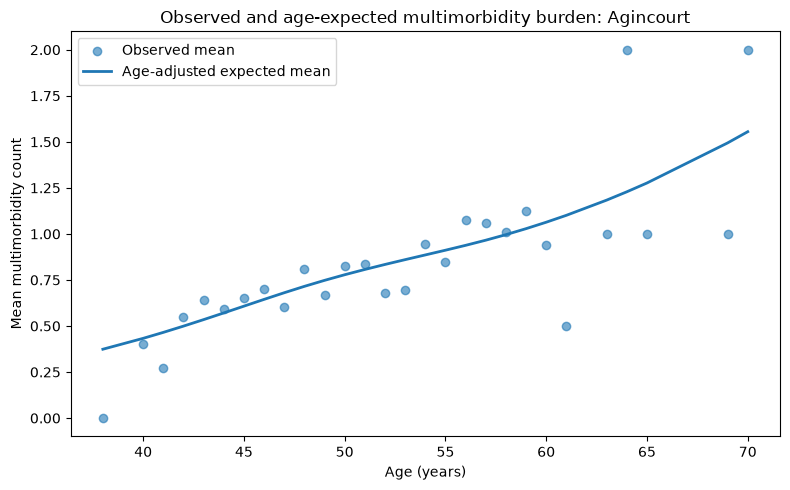

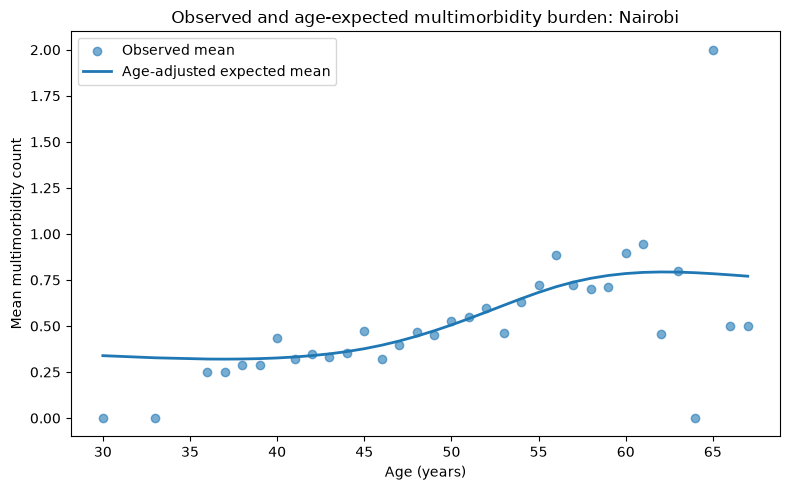

In [51]:
import matplotlib.pyplot as plt


def plot_age_expectation(df, site_name, age_col=AGE_COL):

    plot_df = (
        df
        .groupby(age_col)
        .agg(
            observed=(OUTCOME_COL, 'mean'),
            expected=('expectationPoisson_age', 'mean'),
            n=(OUTCOME_COL, 'size')
        )
        .reset_index()
        .sort_values(age_col)
    )

    plt.figure(figsize=(8, 5))

    plt.scatter(
        plot_df[age_col],
        plot_df['observed'],
        label='Observed mean',
        alpha=0.6
    )

    plt.plot(
        plot_df[age_col],
        plot_df['expected'],
        label='Age-adjusted expected mean',
        linewidth=2
    )

    plt.xlabel('Age (years)')
    plt.ylabel('Mean multimorbidity count')
    plt.title(f'Observed and age-expected multimorbidity burden: {site_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_age_expectation(dff_ag, 'Agincourt')
plot_age_expectation(dff_nai, 'Nairobi')

In [55]:
def get_str(x):
    # This function turns a pandas bin to a meaningful string
    s = str(round(x.left, 2)) + ' - ' + str(round(x.right,2))
    return s

def custom_qcut(ser, contiguous=False):
    # Pandas 3.0 no longer allows strings to be assigned
    # into an int64 Series, so use object dtype.
    ser = ser.astype(object)

    # Keep only valid values for calculating the quantile bins.
    # -999 is your missing-value sentinel.
    sub_ser = ser[ser.notna() & ser.ne(-999)]

    # Create up to 10 quantile bins.
    sub_ser = pd.qcut(
        sub_ser,
        10,
        duplicates='drop'
    )

    # Convert the interval labels to strings using your
    # existing get_str() function.
    sub_ser = sub_ser.apply(get_str).astype(str)

    # Assign back using explicit index-based assignment.
    ser.loc[sub_ser.index] = sub_ser

    return ser


In [58]:
def compress_contiguous(subset, contiguous):
    # Shorten a contiguous list e.g [0-9, 10-19] is converted to [0 - 19] 
    new = {}
    
    for col in subset:
        if col in contiguous:
            if isinstance(subset[col][0], (float,int)):
                new[col] = [str(c) for c in subset[col]]
                continue
            i = -1 if isinstance(subset[col][-1], str) else -2
            new[col] = [subset[col][0].split(' - ')[0] + ' - ' + subset[col][i].split(' - ')[-1]]
            new[col] = new[col] if i == -1 else new[col] + [str(subset[col][-1])]
        else:
            new[col] = [str(c) for c in subset[col]]
    return new

def translate_subset_to_rule(subset):
    # Print the subset as a rule for easier understanding
    desc = ''
    for key, value in subset.items():
        # desc += key + ' = {' + ' OR '.join(value) + '} AND' + '\n'
        desc += key + '{' + ' OR '.join(value) + '} AND' + ' '

    return desc[:-5].replace('_',' ').replace('{', '[').replace('}', ']')

def count_conditions(subset):
    # Split the string by 'AND' and 'OR'
    conditions = subset.replace("AND", "OR").split("OR")
    
    # Count the number of conditions
    condition_count = len(conditions)
    
    return condition_count

In [59]:
dff = dff_ag.copy()

# This is now the expectation used by Autostrat
dff['expectationPoisson'] = dff['expectationPoisson_age']

contiguous = {}
dff_2 = dff.copy()

for col in numeric_columns:
    if col in search_space1:

        # Convert numeric variables into quantile bins
        dff_2[col] = custom_qcut(dff_2[col].copy())

        # Get the unique bin labels
        bins = list(dff_2[col].unique())

        # Remove the missing-value sentinel
        if -999 in bins:
            bins.remove(-999)

        # Sort bins by their lower numerical boundary
        bins = sorted(
            bins,
            key=lambda x: float(x.split(' - ')[0])
        )

        contiguous[col] = bins


In [60]:
# %%time

import scipy.stats as stats

# Scan in the positive direction using defined penalties and num iters

scoring_function = Poisson(direction='positive')
scanner = MDSS(scoring_function)
penalty_values = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 6.5, 10]
# penalty_values = [0.3, 0.8, 1.0, 2.1, 3.5,4.5,5.5,6.5,7.5] # High risk Nairobi 
# penalty_values = [0.05, 0.1, 0.2, 0.5,0.8, 1.0,2.0,3.5, 4.5, 6.5, 9.5] # Low risk 
# penalty_values = [0.05, 0.4, 0.5, 0.8, 1.0,2.0,3.5, 4.0, 4.5] # High risk
# penalty_values = [0.13, 0.8, 1.0, 3.5, 8.5,20.5] # Low risk
num_iters = 10
subset, score = scanner.scan(
    dff_2[search_space1],
    dff_2['MorbidityCount'],
    dff_2['expectationPoisson'],
    cpu=0.95,
    penalty=1.6,
    num_iters=num_iters,
    contiguous=contiguous.copy(),
    mode='ordinal'
)

In [61]:
# %%time

import scipy.stats as stats

# Scan in the positive direction using defined penalties and num iters

scoring_function = Poisson(direction='positive')
scanner = MDSS(scoring_function)
penalty_values = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 6.5, 10]
# penalty_values = [0.3, 0.8, 1.0, 2.1, 3.5,4.5,5.5,6.5,7.5] # High risk Nairobi 
# penalty_values = [0.05, 0.1, 0.2, 0.5,0.8, 1.0,2.0,3.5, 4.5, 6.5, 9.5] # Low risk 
# penalty_values = [0.05, 0.4, 0.5, 0.8, 1.0,2.0,3.5, 4.0, 4.5] # High risk
# penalty_values = [0.13, 0.8, 1.0, 3.5, 8.5,20.5] # Low risk
num_iters = 10
subset, score = scanner.scan(
    dff_2[search_space1],
    dff_2['MorbidityCount'],
    dff_2['expectationPoisson'],
    cpu=0.95,
    penalty=1.6,
    num_iters=num_iters,
    contiguous=contiguous.copy(),
    mode='ordinal'
)



In [58]:
import numpy as np
import pandas as pd
from scipy.stats import norm

def rebuild_table(rows, N, total_count):
    df = pd.DataFrame(rows, columns=['Literals', 'n', 'Count'])

    df['Percent'] = 100 * df['n'] / N
    df['Mean_MM'] = df['Count'] / df['n']

    df['Complement_count'] = total_count - df['Count']
    df['Complement_n'] = N - df['n']
    df['Complement_mean'] = (
        df['Complement_count'] / df['Complement_n']
    )

    df['MBR'] = (
        df['Mean_MM'] / df['Complement_mean']
    )

    se = np.sqrt(
        1 / df['Count'] +
        1 / df['Complement_count']
    )

    df['CI_low'] = np.exp(
        np.log(df['MBR']) - 1.96 * se
    )

    df['CI_high'] = np.exp(
        np.log(df['MBR']) + 1.96 * se
    )

    z = np.log(df['MBR']) / se
    df['p_value'] = 2 * norm.sf(np.abs(z))

    return df


# Agincourt: N=1395, total disease count=1101

ag_reduced = rebuild_table([
    (7, 159, 50),
    (6, 103, 22),
    (5, 159, 51),
    (5, 181, 62),
    (4, 374, 173),
    (3, 383, 185),
    (2, 478, 256),
    (1, 300, 151),
], 1395, 1101)


ag_elevated = rebuild_table([
    (14, 284, 350),
    (6, 31, 65),
    (5, 349, 410),
    (4, 252, 312),
    (3, 371, 422),
    (3, 425, 480),
    (1, 140, 189),
], 1395, 1101)


# Nairobi: N=1939, total disease count=961

nai_reduced = rebuild_table([
    (15, 402, 85),
    (7, 458, 109),
    (5, 546, 140),
    (5, 632, 170),
    (4, 745, 216),
    (3, 584, 163),
    (2, 622, 192),
    (1, 1014, 381),
], 1939, 961)


nai_elevated = rebuild_table([
    (11, 127, 155),
    (10, 155, 175),
    (8, 153, 172),
    (6, 204, 207),
    (4, 237, 232),
    (3, 245, 235),
    (2, 332, 280),
    (1, 370, 285),
], 1939, 961)


for name, df in [
    ('Agincourt reduced', ag_reduced),
    ('Agincourt elevated', ag_elevated),
    ('Nairobi reduced', nai_reduced),
    ('Nairobi elevated', nai_elevated)
]:
    print('\n', name)
    display(
        df[
            [
                'Literals',
                'n',
                'Count',
                'Percent',
                'Mean_MM',
                'Complement_mean',
                'MBR',
                'CI_low',
                'CI_high',
                'p_value'
            ]
        ].round(3)
    )


 Agincourt reduced


,Literals,n,Count,Percent,Mean_MM,Complement_mean,MBR,CI_low,CI_high,p_value
0,7,159,50,11.398,0.314,0.850,0.370,0.278,0.491,0.0
1,6,103,22,7.384,0.214,0.835,0.256,0.168,0.390,0.0
2,5,159,51,11.398,0.321,0.850,0.378,0.285,0.500,0.0
3,5,181,62,12.975,0.343,0.856,0.400,0.310,0.517,0.0
4,4,374,173,26.810,0.463,0.909,0.509,0.433,0.599,0.0
5,3,383,185,27.455,0.483,0.905,0.534,0.456,0.625,0.0
6,2,478,256,34.265,0.536,0.921,0.581,0.505,0.668,0.0
7,1,300,151,21.505,0.503,0.868,0.580,0.489,0.689,0.0



 Agincourt elevated


,Literals,n,Count,Percent,Mean_MM,Complement_mean,MBR,CI_low,CI_high,p_value
0,14,284,350,20.358,1.232,0.676,1.823,1.606,2.070,0.0
1,6,31,65,2.222,2.097,0.760,2.761,2.149,3.547,0.0
2,5,349,410,25.018,1.175,0.661,1.778,1.574,2.009,0.0
3,4,252,312,18.065,1.238,0.690,1.794,1.573,2.045,0.0
4,3,371,422,26.595,1.137,0.663,1.715,1.519,1.937,0.0
5,3,425,480,30.466,1.129,0.640,1.764,1.566,1.987,0.0
6,1,140,189,10.036,1.350,0.727,1.858,1.588,2.173,0.0



 Nairobi reduced


,Literals,n,Count,Percent,Mean_MM,Complement_mean,MBR,CI_low,CI_high,p_value
0,15,402,85,20.732,0.211,0.570,0.371,0.297,0.464,0.0
1,7,458,109,23.620,0.238,0.575,0.414,0.339,0.505,0.0
2,5,546,140,28.159,0.256,0.589,0.435,0.364,0.520,0.0
3,5,632,170,32.594,0.269,0.605,0.444,0.377,0.525,0.0
4,4,745,216,38.422,0.290,0.624,0.465,0.399,0.541,0.0
5,3,584,163,30.119,0.279,0.589,0.474,0.400,0.561,0.0
6,2,622,192,32.078,0.309,0.584,0.529,0.451,0.619,0.0
7,1,1014,381,52.295,0.376,0.627,0.599,0.527,0.682,0.0



 Nairobi elevated


,Literals,n,Count,Percent,Mean_MM,Complement_mean,MBR,CI_low,CI_high,p_value
0,11,127,155,6.550,1.220,0.445,2.744,2.310,3.258,0.0
1,10,155,175,7.994,1.129,0.441,2.563,2.175,3.019,0.0
2,8,153,172,7.891,1.124,0.442,2.545,2.158,3.001,0.0
3,6,204,207,10.521,1.015,0.435,2.335,2.002,2.723,0.0
4,4,237,232,12.223,0.979,0.428,2.285,1.972,2.649,0.0
5,3,245,235,12.635,0.959,0.429,2.238,1.932,2.593,0.0
6,2,332,280,17.122,0.843,0.424,1.990,1.732,2.287,0.0
7,1,370,285,19.082,0.770,0.431,1.788,1.557,2.053,0.0


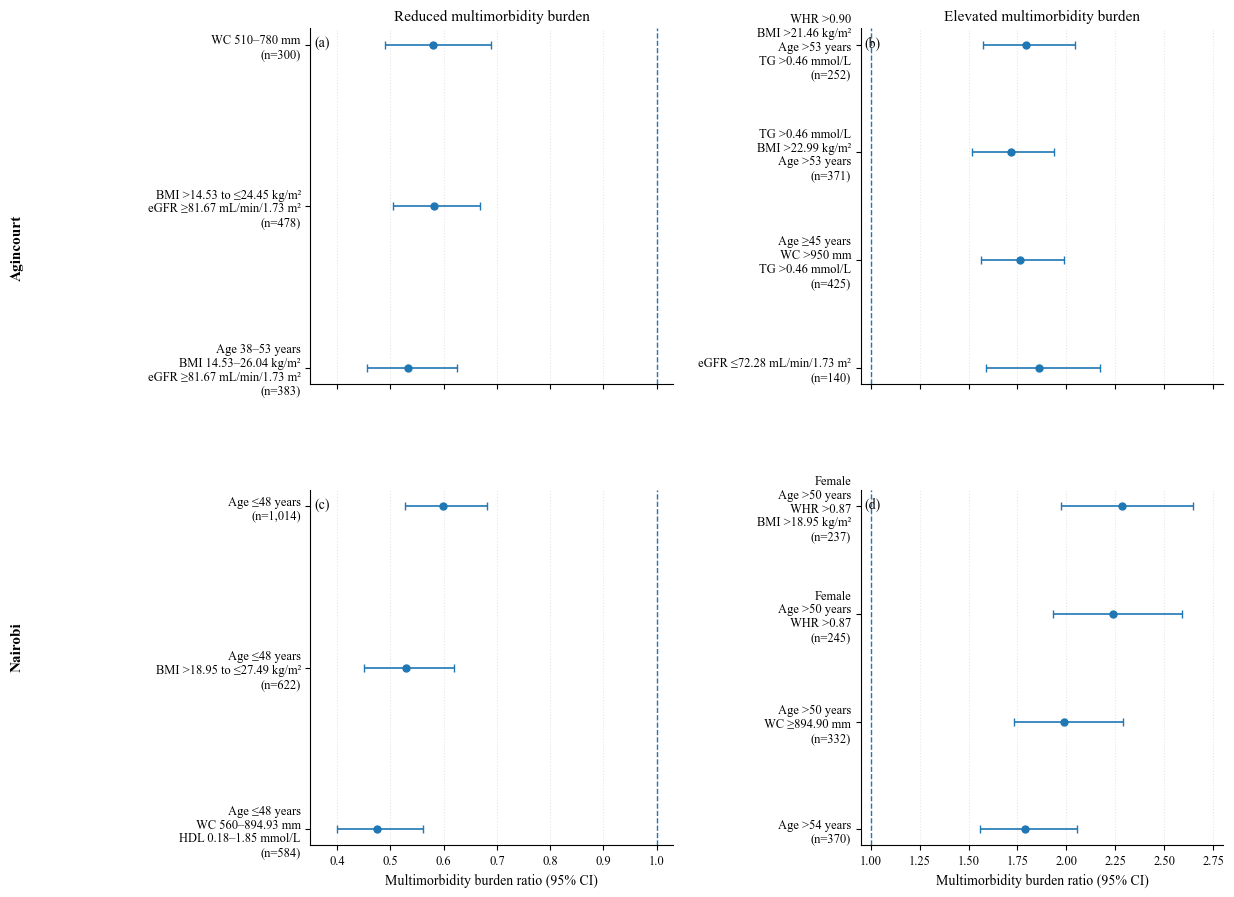

In [60]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

# ============================================================
# LOCKED RESULTS FOR MAIN FIGURE
# MBR, lower 95% CI, upper 95% CI, subgroup n
# ============================================================

data = {

    'AG_reduced': [
        ('WC 510–780 mm',                            300, 0.580, 0.489, 0.689),
        ('BMI >14.53 to ≤24.45 kg/m²\n'
         'eGFR ≥81.67 mL/min/1.73 m²',              478, 0.581, 0.505, 0.668),
        ('Age 38–53 years\n'
         'BMI 14.53–26.04 kg/m²\n'
         'eGFR ≥81.67 mL/min/1.73 m²',              383, 0.534, 0.456, 0.625),
    ],

    'AG_elevated': [
        ('WHR >0.90\n'
         'BMI >21.46 kg/m²\n'
         'Age >53 years\n'
         'TG >0.46 mmol/L',                         252, 1.794, 1.573, 2.045),
        ('TG >0.46 mmol/L\n'
         'BMI >22.99 kg/m²\n'
         'Age >53 years',                           371, 1.715, 1.519, 1.937),
        ('Age ≥45 years\n'
         'WC >950 mm\n'
         'TG >0.46 mmol/L',                         425, 1.764, 1.566, 1.987),
        ('eGFR ≤72.28 mL/min/1.73 m²',              140, 1.858, 1.588, 2.173),
    ],

    'NAI_reduced': [
        ('Age ≤48 years',                           1014, 0.599, 0.527, 0.682),
        ('Age ≤48 years\n'
         'BMI >18.95 to ≤27.49 kg/m²',              622, 0.529, 0.451, 0.619),
        ('Age ≤48 years\n'
         'WC 560–894.93 mm\n'
         'HDL 0.18–1.85 mmol/L',                    584, 0.474, 0.400, 0.561),
    ],

    'NAI_elevated': [
        ('Female\n'
         'Age >50 years\n'
         'WHR >0.87\n'
         'BMI >18.95 kg/m²',                        237, 2.285, 1.972, 2.649),
        ('Female\n'
         'Age >50 years\n'
         'WHR >0.87',                               245, 2.238, 1.932, 2.593),
        ('Age >50 years\n'
         'WC ≥894.90 mm',                           332, 1.990, 1.732, 2.287),
        ('Age >54 years',                           370, 1.788, 1.557, 2.053),
    ]
}


def forest_panel(ax, rows, panel):

    # Reverse so first listed subgroup appears at the top
    rows = rows[::-1]

    labels = [f'{r[0]}\n(n={r[1]:,})' for r in rows]
    mbr = np.array([r[2] for r in rows])
    low = np.array([r[3] for r in rows])
    high = np.array([r[4] for r in rows])

    y = np.arange(len(rows))

    ax.errorbar(
        mbr,
        y,
        xerr=np.vstack([mbr - low, high - mbr]),
        fmt='o',
        markersize=5,
        capsize=3,
        linewidth=1.2
    )

    ax.axvline(1, linestyle='--', linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(labels)

    ax.grid(axis='x', linestyle=':', alpha=0.30)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.text(
        0.01, 0.98, f'({panel})',
        transform=ax.transAxes,
        ha='left', va='top'
    )


# ============================================================
# COMBINED 2 × 2 FIGURE
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(12.5, 9.5),
    sharex='col'
)

forest_panel(axes[0, 0], data['AG_reduced'],  'a')
forest_panel(axes[0, 1], data['AG_elevated'], 'b')
forest_panel(axes[1, 0], data['NAI_reduced'],  'c')
forest_panel(axes[1, 1], data['NAI_elevated'], 'd')

# Column headings
axes[0, 0].set_title('Reduced multimorbidity burden')
axes[0, 1].set_title('Elevated multimorbidity burden')

# Scales
for ax in axes[:, 0]:
    ax.set_xlim(0.35, 1.03)

for ax in axes[:, 1]:
    ax.set_xlim(0.95, 2.80)

# Bottom axis labels only
axes[1, 0].set_xlabel('Multimorbidity burden ratio (95% CI)')
axes[1, 1].set_xlabel('Multimorbidity burden ratio (95% CI)')

# Row labels
fig.text(
    0.015, 0.71, 'Agincourt',
    rotation=90,
    va='center',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

fig.text(
    0.015, 0.29, 'Nairobi',
    rotation=90,
    va='center',
    ha='center',
    fontsize=11,
    fontweight='bold'
)

plt.subplots_adjust(
    left=0.25,
    right=0.98,
    top=0.94,
    bottom=0.08,
    wspace=0.52,
    hspace=0.30
)

plt.savefig(
    'figure_3_subgroup_discovery.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_3_subgroup_discovery.png',
    dpi=400,
    bbox_inches='tight'
)

plt.show()

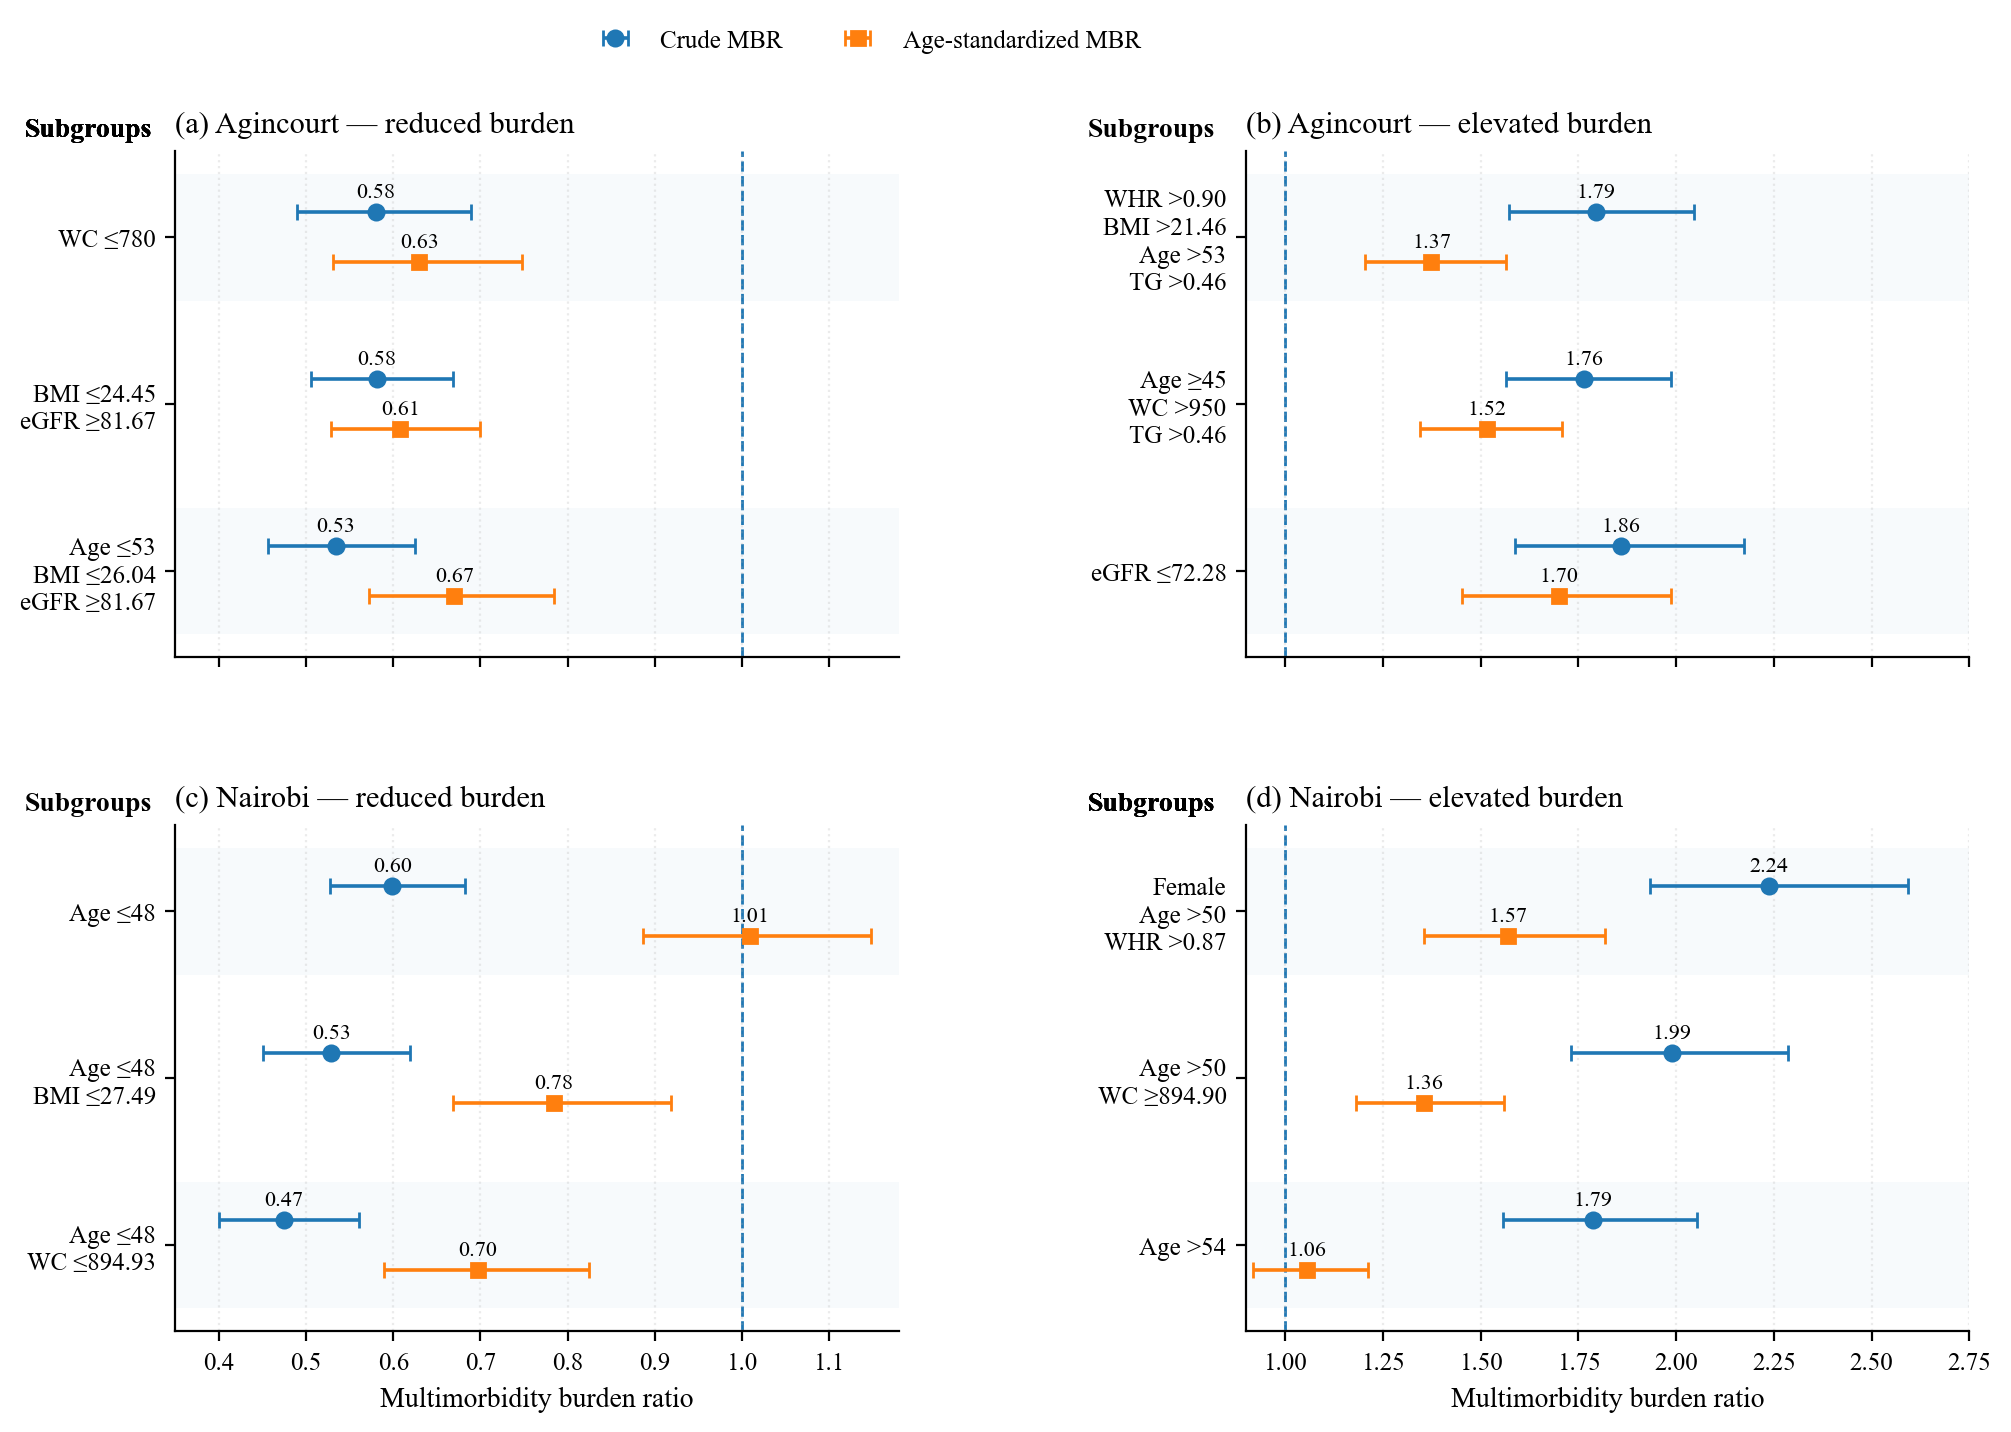

In [171]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# STYLE
# ============================================================

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})


# ============================================================
# LOCKED RESULTS
#
# Each tuple:
# label,
# crude MBR, crude CI low, crude CI high,
# age-standardized MBR, age-standardized CI low/high
# ============================================================

results = {

    # --------------------------------------------------------
    # Agincourt — reduced
    # --------------------------------------------------------
    'AG_reduced': [
        (
            'WC ≤780',
            0.580, 0.489, 0.689,
            0.630, 0.531, 0.748
        ),
        (
            'BMI ≤24.45\n'
            'eGFR ≥81.67',
            0.581, 0.505, 0.668,
            0.608, 0.528, 0.699
        ),
        (
            'Age ≤53\n'
            'BMI ≤26.04\n'
            'eGFR ≥81.67',
            0.534, 0.456, 0.625,
            0.670, 0.572, 0.784
        ),
    ],


    # --------------------------------------------------------
    # Agincourt — elevated
    # --------------------------------------------------------
    'AG_elevated': [
        (
            'WHR >0.90\n'
            'BMI >21.46\n'
            'Age >53\n'
            'TG >0.46',
            1.794, 1.573, 2.045,
            1.374, 1.205, 1.566
        ),
        (
            'Age ≥45\n'
            'WC >950\n'
            'TG >0.46',
            1.764, 1.566, 1.987,
            1.517, 1.346, 1.709
        ),
        (
            'eGFR ≤72.28',
            1.858, 1.588, 2.173,
            1.700, 1.453, 1.988
        ),
    ],


    # --------------------------------------------------------
    # Nairobi — reduced
    # --------------------------------------------------------
    'NAI_reduced': [
        (
            'Age ≤48',
            0.599, 0.527, 0.682,
            1.009, 0.887, 1.148
        ),
        (
            'Age ≤48\n'
            'BMI ≤27.49',
            0.529, 0.451, 0.619,
            0.784, 0.669, 0.919
        ),
        (
            'Age ≤48\n'
            'WC ≤894.93',
            0.474, 0.400, 0.561,
            0.697, 0.589, 0.825
        ),
    ],


    # --------------------------------------------------------
    # Nairobi — elevated
    # --------------------------------------------------------
    'NAI_elevated': [
        (
            'Female\n'
            'Age >50\n'
            'WHR >0.87',
            2.238, 1.932, 2.593,
            1.570, 1.355, 1.819
        ),
        (
            'Age >50\n'
            'WC ≥894.90',
            1.990, 1.732, 2.287,
            1.356, 1.180, 1.559
        ),
        (
            'Age >54',
            1.788, 1.557, 2.053,
            1.056, 0.919, 1.212
        ),
    ]
}


# ============================================================
# PANEL FUNCTION
# ============================================================

def forest_panel(ax, rows, panel, title, xlim):

    # Reverse so first listed rule is displayed at top
    rows = rows[::-1]

    labels = [r[0] for r in rows]

    crude = np.array([r[1] for r in rows])
    crude_low = np.array([r[2] for r in rows])
    crude_high = np.array([r[3] for r in rows])

    adj = np.array([r[4] for r in rows])
    adj_low = np.array([r[5] for r in rows])
    adj_high = np.array([r[6] for r in rows])

    y = np.arange(len(rows))

    offset = 0.15

    # --------------------------------------------------------
    # Alternating row background
    # --------------------------------------------------------

    for i in range(len(rows)):
        if i % 2 == 0:
            ax.axhspan(
                i - 0.38,
                i + 0.38,
                alpha=0.035,
                zorder=0
            )

    # --------------------------------------------------------
    # Crude estimates
    # --------------------------------------------------------

    crude_err = np.vstack([
        crude - crude_low,
        crude_high - crude
    ])

    ax.errorbar(
        crude,
        y + offset,
        xerr=crude_err,
        fmt='o',
        markersize=5.5,
        capsize=3,
        linewidth=1.3,
        label='Crude MBR',
        zorder=3
    )

    # --------------------------------------------------------
    # Age-standardized estimates
    # --------------------------------------------------------

    adj_err = np.vstack([
        adj - adj_low,
        adj_high - adj
    ])

    ax.errorbar(
        adj,
        y - offset,
        xerr=adj_err,
        fmt='s',
        markersize=5.2,
        capsize=3,
        linewidth=1.3,
        label='Age-standardized MBR',
        zorder=3
    )

    # --------------------------------------------------------
    # Numeric MBR labels
    # --------------------------------------------------------

    xrange = xlim[1] - xlim[0]
    shift = 0.025 * xrange

    for yi, value in zip(y + offset, crude):
        ax.text(
            value,
            yi + 0.18,
            f'{value:.2f}',
            fontsize=8,
            va='top',
            ha='center'
        )

    for yi, value in zip(y - offset, adj):
        ax.text(
            value ,
            yi + 0.18,
            f'{value:.2f}',
            fontsize=8,
            va='top',
            ha='center'
        )
    # ax.text(0.65, 2.64, "Subgroups",
    #                va="center", ha="center", fontsize=11, fontweight='bold')

    # axes[0, 1].text
    for a in axes[:, 0]:
        if a == axes[0, 0] or ax == axes[0, 1]:
            a.text(0.25, 2.64, "Subgroups",
                                           va="center", ha="center", fontsize=10, fontweight='bold')
    
        if a == axes[1, 0] or ax == axes[1, 1]:
            a.text(1.47, 2.64, "Subgroups",
                                           va="center", ha="center", fontsize=10, fontweight='bold')


    # --------------------------------------------------------
    # Null line
    # --------------------------------------------------------

    ax.axvline(
        1.0,
        linestyle='--',
        linewidth=1.0,
        zorder=1
    )

    # --------------------------------------------------------
    # Axes
    # --------------------------------------------------------

    ax.set_yticks(y)
    ax.set_yticklabels(labels)

    ax.set_xlim(*xlim)

    ax.grid(
        axis='x',
        linestyle=':',
        alpha=0.25
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.set_title(
        f'({panel}) {title}',
        loc='left',
        pad=7
    )


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(11.5, 7.2),
    sharex='col',
    dpi=200
)

# ------------------------------------------------------------
# Panels
# ------------------------------------------------------------

forest_panel(
    axes[0, 0],
    results['AG_reduced'],
    'a',
    'Agincourt — reduced burden',
    (0.35, 1.18)
)

forest_panel(
    axes[0, 1],
    results['AG_elevated'],
    'b',
    'Agincourt — elevated burden',
    (0.90, 2.75)
)

forest_panel(
    axes[1, 0],
    results['NAI_reduced'],
    'c',
    'Nairobi — reduced burden',
    (0.35, 1.18)
)

forest_panel(
    axes[1, 1],
    results['NAI_elevated'],
    'd',
    'Nairobi — elevated burden',
    (0.90, 2.75)
)


# ============================================================
# AXIS LABELS
# ============================================================

axes[1, 0].set_xlabel(
    'Multimorbidity burden ratio'
)

axes[1, 1].set_xlabel(
    'Multimorbidity burden ratio'
)


# ============================================================
# SHARED LEGEND
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False
)


# ============================================================
# SPACING
# ============================================================

plt.subplots_adjust(
    left=0.20,
    right=0.98,
    top=0.91,
    bottom=0.09,
    wspace=0.48,
    hspace=0.33
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    'figure_4_crude_age_standardized_subgroups.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_4_crude_age_standardized_subgroups.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [62]:
# %%time

import scipy.stats as stats

# Scan in the positive direction using defined penalties and num iters

scoring_function = Poisson(direction='negative') # AG - positive - 1.6, 0.1, 1.0, 2.5, 6.5; negative - 1.5, 1.0, 2.0, 2.5, 7.0, 0.5
scanner = MDSS(scoring_function) # NAI - postive - 0.5, 1.0, 1.5, 2.5, 3.5, 5.5, 7.5; negative - 0.5, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 6.0, 8.5
penalty_values = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 6.5, 10]
# penalty_values = [0.3, 0.8, 1.0, 2.1, 3.5,4.5,5.5,6.5,7.5] # High risk Nairobi 
# penalty_values = [0.05, 0.1, 0.2, 0.5,0.8, 1.0,2.0,3.5, 4.5, 6.5, 9.5] # Low risk 
# penalty_values = [0.05, 0.4, 0.5, 0.8, 1.0,2.0,3.5, 4.0, 4.5] # High risk
# penalty_values = [0.13, 0.8, 1.0, 3.5, 8.5,20.5] # Low risk
num_iters = 10
subset, score = scanner.scan(
    dff_2[search_space1],
    dff_2['MorbidityCount'],
    dff_2['expectationPoisson'],
    cpu=0.95,
    penalty=8.5,
    num_iters=num_iters,
    contiguous=contiguous.copy(),
    mode='ordinal'
)
subset

{'waist_circumference_phase1': ['510.0 - 740.0', '740.0 - 780.0']}

In [70]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# --- your existing setup ---
scoring_function = Poisson(direction='negative')
scanner = MDSS(scoring_function)
# penalty_values = [0.13, 0.8, 1.0, 3.5, 8.5] # Low risk
# penalty_values = [0.05, 1.6, 0.1, 1.0, 2.5, 6.5]
penalty_values = [1.5, 1.0, 2.0, 2.5, 7.0, 0.5] # Agincourt - negative
# penalty_values = [0.05, 0.5, 1, 1.5, 2, 2.5, 3, 6.5]
num_iters = 10

# Initialize containers
subset_results1 = []
score_results = []
size_results = []
size_percent = []
counts_percent = []
IDR_results = []
z_idr_list, p_idr_list = [], []
idr_ci_low, idr_ci_high = [], []

# NEW: complement-based effect + CI
RR_comp_results = []
rr_ci_low, rr_ci_high = [], []
z_rr_list, p_rr_list = [], []

# Bookkeeping
count_results = []
disease_counts = []
events_sub_list, events_comp_list, events_pop_list = [], [], []
rate_sub_list, rate_comp_list, rate_pop_list = [], [], []
n_sub_list, n_comp_list, n_pop_list = [], [], []
dataframes = {}
dataframes_complement = {}

for penalty in penalty_values:
    subset, score = scanner.scan(
        dff_2[search_space1], dff_2['MorbidityCount'], dff_2['expectationPoisson'],
        cpu=0.95, penalty=penalty, num_iters=num_iters, contiguous=contiguous.copy()
    )
    to_choose = dff_2[subset.keys()].isin(subset).all(axis=1)
    temp_df = dff_2.loc[to_choose]
    not_temp_df = dff_2.loc[~to_choose]

    n_sub = int(len(temp_df))
    n_comp = int(len(not_temp_df))
    n_pop  = int(len(dff_2))

    # Save grouped DataFrames (optional, useful downstream)
    dataframes[f'df_{penalty}'] = temp_df
    dataframes_complement[f'df_{penalty}'] = not_temp_df

    # Events (sum of counts)
    E_sub  = float(temp_df['MorbidityCount'].sum())
    E_comp = float(not_temp_df['MorbidityCount'].sum())
    E_pop  = float(dff_2['MorbidityCount'].sum())

    # Incidence densities (counts/person)
    r_sub  = E_sub / max(n_sub, 1)
    r_comp = E_comp / max(n_comp, 1)
    r_pop  = E_pop / max(n_pop, 1)

    # --- IDR vs population (descriptive; pop includes sub so dependence is ignored in SE) ---
    IDR = r_sub / r_pop if r_pop > 0 else np.nan
    # continuity correction for SE if zero events in either stratum
    eps_sub = E_sub if E_sub > 0 else 0.5
    eps_pop = E_pop if E_pop > 0 else 0.5
    if np.isfinite(IDR) and IDR > 0:
        log_IDR = np.log(IDR)
        SE_log_IDR = np.sqrt((1.0/eps_sub) + (1.0/eps_pop))
        z_idr = log_IDR / SE_log_IDR
        p_idr = stats.norm.sf(abs(z_idr)) * 2
        ci_idr_lo = np.exp(log_IDR - 1.96*SE_log_IDR)
        ci_idr_hi = np.exp(log_IDR + 1.96*SE_log_IDR)
    else:
        log_IDR = np.nan
        SE_log_IDR = np.nan
        z_idr = np.nan
        p_idr = np.nan
        ci_idr_lo = np.nan
        ci_idr_hi = np.nan

    # --- RR vs complement (preferred for inference/forest plots; disjoint groups => independence) ---
    if r_comp > 0:
        RR_comp = r_sub / r_comp
    else:
        RR_comp = np.nan
    eps_comp = E_comp if E_comp > 0 else 0.5
    if np.isfinite(RR_comp) and RR_comp > 0:
        log_RR = np.log(RR_comp)
        SE_log_RR = np.sqrt((1.0/eps_sub) + (1.0/eps_comp))
        z_rr = log_RR / SE_log_RR
        p_rr = stats.norm.sf(abs(z_rr)) * 2
        ci_rr_lo = np.exp(log_RR - 1.96*SE_log_RR)
        ci_rr_hi = np.exp(log_RR + 1.96*SE_log_RR)
    else:
        log_RR = np.nan
        SE_log_RR = np.nan
        z_rr = np.nan
        p_rr = np.nan
        ci_rr_lo = np.nan
        ci_rr_hi = np.nan

    # Descriptive sizes/percents
    size_pct = (n_sub / n_pop * 100.0) if n_pop > 0 else np.nan
    count_pct = (E_sub / E_pop * 100.0) if E_pop > 0 else np.nan

    # Rule (literals) and count
    rule = translate_subset_to_rule(compress_contiguous(subset, contiguous))
    n_literals = count_conditions(rule)

    # Append to containers
    subset_results1.append(rule)
    count_results.append(n_literals)
    score_results.append(np.round(score, 3))
    size_results.append(n_sub)
    size_percent.append(np.round(size_pct, 2))
    counts_percent.append(np.round(count_pct, 2))
    IDR_results.append(np.round(IDR, 3))
    z_idr_list.append(z_idr)
    p_idr_list.append(p_idr)
    idr_ci_low.append(ci_idr_lo)
    idr_ci_high.append(ci_idr_hi)

    RR_comp_results.append(RR_comp if np.isfinite(RR_comp) else np.nan)
    rr_ci_low.append(ci_rr_lo)
    rr_ci_high.append(ci_rr_hi)
    z_rr_list.append(z_rr)
    p_rr_list.append(p_rr)

    disease_counts.append(E_sub)
    events_sub_list.append(E_sub)
    events_comp_list.append(E_comp)
    events_pop_list.append(E_pop)
    rate_sub_list.append(r_sub)
    rate_comp_list.append(r_comp)
    rate_pop_list.append(r_pop)
    n_sub_list.append(n_sub)
    n_comp_list.append(n_comp)
    n_pop_list.append(n_pop)

# --- Final tidy table for analysis/plots ---
results_df = pd.DataFrame({
    'penalty': penalty_values,
    'subgroup_rule': subset_results1,
    'n_literals': count_results,
    'n_sub': n_sub_list,
    'n_comp': n_comp_list,
    'size_percent': size_percent,
    'events_sub': events_sub_list,
    'events_comp': events_comp_list,
    'rate_sub': rate_sub_list,
    'rate_comp': rate_comp_list,
    'rate_pop': rate_pop_list,
    # IDR vs population (descriptive)
    'IDR_vs_pop': IDR_results,
    'IDR_CI95_low': idr_ci_low,
    'IDR_CI95_high': idr_ci_high,
    'z_IDR_vs_pop': z_idr_list,
    'p_IDR_vs_pop': p_idr_list,
    # RR vs complement (preferred for inference/forest plot)
    'RR_vs_comp': RR_comp_results,
    'RR_CI95_low': rr_ci_low,
    'RR_CI95_high': rr_ci_high,
    'z_RR_vs_comp': z_rr_list,
    'p_RR_vs_comp': p_rr_list,
    # scoring
    'score': score_results,
    # optional bookkeeping
    'events_pop': events_pop_list,
    'n_pop': n_pop_list
})

# Nice printing
# with pd.option_context('display.max_colwidth', 120):
#     results_df.round(3)
# Optional: save
# results_df.to_csv('autostrat_subgroup_effects.csv', index=False)

In [71]:
results_df

,penalty,subgroup_rule,n_literals,n_sub,n_comp,size_percent,events_sub,events_comp,rate_sub,rate_comp,...,z_IDR_vs_pop,p_IDR_vs_pop,RR_vs_comp,RR_CI95_low,RR_CI95_high,z_RR_vs_comp,p_RR_vs_comp,score,events_pop,n_pop
0,1.5,egfr c phase1[81.67 - 163.56] AND bmi c phase1...,4,173,1222,12.40,63.0,1038.0,0.364162,0.849427,...,-5.970865,2.359986e-09,0.428715,0.332444,0.552864,-6.527399,6.692177e-11,14.506,1101.0,1395
1,1.0,friedewald ldl c phase1[-3.31 - 3.1] AND trigl...,5,165,1230,11.83,57.0,1044.0,0.345455,0.848780,...,-6.082356,1.184296e-09,0.407001,0.311754,0.531348,-6.608829,3.873727e-11,17.269,1101.0,1395
2,2.0,bmi c phase1[14.53 - 24.45] AND egfr c phase1[...,2,478,917,34.27,256.0,845.0,0.535565,0.921483,...,-5.588358,2.292273e-08,0.581199,0.505356,0.668424,-7.606493,2.816345e-14,14.512,1101.0,1395
3,2.5,triglycerides phase1[0.25 - 1.15] AND friedewa...,3,310,1085,22.22,148.0,953.0,0.477419,0.878341,...,-5.741677,9.374346e-09,0.543547,0.457120,0.646314,-6.900123,5.195736e-12,10.955,1101.0,1395
4,7.0,bmi c phase1[14.53 - 22.99],1,421,974,30.18,239.0,862.0,0.567696,0.885010,...,-4.617292,3.887797e-06,0.641457,0.555828,0.740278,-6.073721,1.249796e-09,5.037,1101.0,1395
5,0.5,egfr c phase1[4.18 - 111.93] AND ses site quin...,9,24,1371,1.72,0.0,1101.0,0.000000,0.803063,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,13.437,1101.0,1395


In [72]:
results_df.to_csv('reviewer_revision_outputs/agincourt_low_risk_1.csv', index=False)

In [ ]:
# ============================================================
# COLUMN NAMES
# ============================================================

AGE_COL   = 'age_phase1'
SEX_COL   = 'sex'

BMI_COL   = 'bmi_c_phase1'
WHR_COL   = 'waist_hip_r_c_phase1'
WC_COL    = 'waist_circumference_phase1'
TRIG_COL  = 'triglycerides_phase1'
EGFR_COL  = 'egfr_c_phase1'
HDL_COL   = 'hdl_phase1'

CKD_COL   = 'ckd_c_phase1'
DM_COL    = 'diabetes_status_c_phase1'
HTN_COL   = 'hypertension_status_c_phase1'
CVD_COL   = 'cvd_status_phase1'

OUTCOME_COL = 'MorbidityCount'

# AWI-Gen coding was commonly 0 = female, 1 = male.
# CONFIRM this in your actual dataframe before running the rules.
FEMALE_VALUE = 0

In [ ]:
print(dff_ag[SEX_COL].value_counts(dropna=False))
print(dff_nai[SEX_COL].value_counts(dropna=False))

0    843
1    552
Name: sex, dtype: int64
0    1054
1     885
Name: sex, dtype: int64


In [ ]:
display(
    dff_nai.loc[
        dff_nai[WHR_COL] > 1.5,
        [AGE_COL, SEX_COL, WHR_COL, BMI_COL, WC_COL, OUTCOME_COL]
    ].sort_values(WHR_COL, ascending=False)
)

,age_phase1,sex,waist_hip_r_c_phase1,bmi_c_phase1,waist_circumference_phase1,MorbidityCount
765,42,1,9.02,24.87,920.0,0
1924,46,1,8.11,18.50,730.0,0


In [133]:
for ax in axes[:, 0]:
    print(ax)
    

for ax in axes[:, 1]:
    print(ax)

Axes(0.2,0.558069;0.314516x0.351931)
Axes(0.2,0.09;0.314516x0.351931)
Axes(0.665484,0.558069;0.314516x0.351931)
Axes(0.665484,0.09;0.314516x0.351931)


In [139]:
for ax in axes[:, 0]:
    if ax == axes[0, 0] or ax == axes[0, 1]:
        print(ax)
    
if ax == axes[1, 0] or ax == axes[1, 1]:
    print(ax)

Axes(0.2,0.558069;0.314516x0.351931)
Axes(0.2,0.09;0.314516x0.351931)


In [151]:
axes[0, 1]

<Axes: title={'left': '(b) Agincourt — elevated burden'}>